In [1]:
!pip install livelossplot optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 42.4 MB/s eta 0:00:00


In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer, models
import numpy as np
import pandas as pd
import time
import pathlib
from livelossplot import PlotLosses

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
og_model_name = 'BAAI/bge-base-en-v1.5'
inter_dims = 364
target_dims = 6
physical_batch_size = 256
accumulation_steps = 4  
num_epochs = 50

In [5]:
base_model = SentenceTransformer(og_model_name, device=device)

og_dims = base_model.get_sentence_embedding_dimension()

dense_layer_1 = models.Dense(
    in_features=og_dims,
    out_features=256,
    activation_function=torch.nn.GELU()
)

dense_layer_2 = models.Dense(
    in_features=256,
    out_features=64,
    activation_function=torch.nn.GELU()
)

dense_layer_3 = models.Dense(
    in_features=64,
    out_features=target_dims,
    activation_function=None
)

class STModuleWrapper(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.module = module

    def forward(self, features):
        emb = features['sentence_embedding']
        emb = self.module(emb)
        features.update({'sentence_embedding': emb})
        return features
    
norm_layer_1 = STModuleWrapper(nn.LayerNorm(256))
norm_layer_2 = STModuleWrapper(nn.LayerNorm(64))

modules_with_reduction = [
    base_model,
    dense_layer_1,
    norm_layer_1,
    dense_layer_2,
    norm_layer_2,
    dense_layer_3,
]

model = SentenceTransformer(modules=modules_with_reduction)
model.to(device)

for param in model[0].parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
training_data = pd.read_csv('/content/drive/MyDrive/mixed_questions_total_train_dataset.csv')
validation_data = pd.read_csv('/content/drive/MyDrive/mixed_questions_total_val_dataset.csv')
test_data = pd.read_csv('/content/drive/MyDrive/mixed_questions_total_test_dataset.csv')
print(f"Training samples: {len(training_data)}, Validation samples: {len(validation_data)}, Test samples: {len(test_data)}")
output_dir = pathlib.Path('/content/drive/MyDrive/models')
output_dir.mkdir(parents=True, exist_ok=True)

Training samples: 10638, Validation samples: 1519, Test samples: 3042


In [8]:
class TextVectorDataset(Dataset):
    def __init__(self, dataframe):
        # We assume the first column is text, and the last 6 are the vector
        self.texts = dataframe.iloc[:, 0].values
        # Get the last 6 columns and convert to float32 (standard for PyTorch)
        self.vectors = dataframe.iloc[:, -6:].values.astype('float32')

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        vector = self.vectors[idx]
        return text, vector

# Initialize Datasets
train_ds = TextVectorDataset(training_data)
val_ds = TextVectorDataset(validation_data)

train_loader = DataLoader(train_ds, batch_size=physical_batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=physical_batch_size, shuffle=False)
output_dir = pathlib.Path('/content/drive/MyDrive/models')
output_dir.mkdir(parents=True, exist_ok=True)

class LogCoshLoss(nn.Module):
    def __init__(self):
        super(LogCoshLoss, self).__init__()

    def forward(self, pred, target):
        diff = pred - target
        # STABILITY FIX: Pure torch.cosh overflows for diff > 88. 
        # Use Softplus approximation for large values.
        return torch.mean(diff + F.softplus(-2. * diff) - torch.log(torch.tensor(2.)))

class CosineSimilarityLoss(nn.Module):
    def __init__(self):
        super(CosineSimilarityLoss, self).__init__()

    def forward(self, pred, target):
        # DIMENSION FIX: Explicitly specify dim=1 to compare vectors row-by-row
        cosine_sim = F.cosine_similarity(pred, target, dim=1)
        return torch.mean(1 - cosine_sim)

class SupCRLoss(nn.Module):
    def __init__(self, temperature=0.1, threshold=0.3): # Tuned defaults
        super(SupCRLoss, self).__init__()
        self.temperature = temperature
        self.threshold = threshold 

    def forward(self, features, targets):
        """
        features: [batch_size, dim] (Your predicted vectors)
        targets:  [batch_size, dim] (Your ground truth vectors)
        """
        # Ensure features are normalized for contrastive learning
        features = F.normalize(features, dim=1)
        
        device = features.device
        batch_size = features.shape[0]

        # --- BUG FIX START ---
        # The original code flattened targets to (Batch*Dim, 1). 
        # We must keep them as (Batch, Dim) to calculate vector-to-vector distance.
        if len(targets.shape) == 1:
            targets = targets.view(-1, 1)
        # --- BUG FIX END ---

        # 1. Create "Positive" Mask based on Vector Distance (L1 or L2)
        # cdist computes distance between every pair of vectors in the batch
        # p=1 (Manhattan) is often robust for 'feature degrees'
        target_dist = torch.cdist(targets, targets, p=1) 
        
        # Mask: 1 if vector_i is close to vector_j
        mask = torch.le(target_dist, self.threshold).float().to(device)

        # Remove self-contrast (diagonals)
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # 2. Compute Contrastive Logits
        anchor_dot_contrast = torch.div(
            torch.matmul(features, features.T),
            self.temperature
        )
        
        # Stability shift
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # 3. Compute Loss
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6)

        # Calculate Mean of Positives
        mask_pos_pairs = mask.sum(1)
        # Avoid division by zero for anchors with no positives
        mask_pos_pairs = torch.where(mask_pos_pairs < 1e-6, 1.0, mask_pos_pairs)
        
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_pos_pairs

        # If an anchor has NO positives, we don't want it to contribute 0 to the mean, 
        # we want to ignore it or it drags loss down artificially.
        # But standard implementation often just leaves it as is.
        loss = - mean_log_prob_pos
        return loss.mean()

class L1Loss(nn.Module):
    def __init__(self):
        super(L1Loss, self).__init__()

    def forward(self, pred):
        specialized_dims = pred[:, :-1]  # Assuming the last dimension is not part of the specialized features
        return torch.mean(torch.abs(specialized_dims))

class CompositeLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0, delta=0.05, gamma=0.1, gamma_t=0.1, gamma_threshold=0.3):
        super(CompositeLoss, self).__init__()
        self.alpha = alpha   # Weight for Magnitude (LogCosh)
        self.beta = beta     # Weight for Direction (Cosine)
        self.delta = delta   # Weight for L1
        self.gamma = gamma   # Weight for SupCR
        self.gamma_t = gamma_t  # Weight for SupCR temperature
        self.gamma_threshold = gamma_threshold  # Weight for SupCR threshold
        self.log_cosh = LogCoshLoss()
        self.cosine = CosineSimilarityLoss()
        self.supcr = SupCRLoss(temperature=gamma_t, threshold=gamma_threshold)
        self.l1 = L1Loss()

    def forward(self, pred, target):
        loss_mag = self.log_cosh(pred, target)
        loss_dir = self.cosine(pred, target)
        
        # SupCR usually works on the latent features, but here we enforce
        # clustering on the OUTPUT vectors themselves.
        loss_clust = self.supcr(pred, target)

        loss_l1 = self.l1(pred)
        
        return (self.alpha * loss_mag) + (self.beta * loss_dir) + (self.gamma * loss_clust) + (self.delta * loss_l1)

In [9]:
class CosineSimilarityLoss(nn.Module):
    def __init__(self):
        super(CosineSimilarityLoss, self).__init__()

    def forward(self, pred, target):
        cosine_sim = F.cosine_similarity(pred, target, dim=1)
        return torch.mean(1 - cosine_sim)


class SupCRLoss(nn.Module):
    def __init__(self, temperature=0.1, threshold=0.3):
        super(SupCRLoss, self).__init__()
        self.temperature = temperature
        self.threshold = threshold

    def forward(self, features, targets):
        """
        features: [batch_size, 1]  -- single dimension slice
        targets:  [batch_size, 1]  -- corresponding label slice
        """
        features = F.normalize(features, dim=1)
        device = features.device
        batch_size = features.shape[0]

        if targets.dim() == 1:
            targets = targets.unsqueeze(1)

        # L1 distance between scalar labels for this dimension
        target_dist = torch.cdist(targets.float(), targets.float(), p=1)

        # Positive mask: pairs whose labels are close
        mask = torch.le(target_dist, self.threshold).float().to(device)

        # Remove self-contrast
        logits_mask = torch.ones_like(mask).scatter_(
            1, torch.arange(batch_size).view(-1, 1).to(device), 0
        )
        mask = mask * logits_mask

        # Contrastive logits
        anchor_dot_contrast = torch.div(
            torch.matmul(features, features.T), self.temperature
        )
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6)

        mask_pos_pairs = mask.sum(1)
        mask_pos_pairs = torch.where(mask_pos_pairs < 1e-6, 
                                     torch.ones_like(mask_pos_pairs), 
                                     mask_pos_pairs)
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_pos_pairs

        # Only include anchors that actually have positives
        has_positives = (mask.sum(1) > 0).float()
        loss = -(mean_log_prob_pos * has_positives).sum() / (has_positives.sum() + 1e-6)
        return loss


class PerDimSupCRLoss(nn.Module):
    """
    Applies SupCR independently to each of the 6 output dimensions.
    Each dim is supervised by its corresponding label component.
    This enforces that each dimension captures its own semantic direction
    without conflating the 6 components.
    """
    def __init__(self, temperature=0.1, threshold=0.3):
        super(PerDimSupCRLoss, self).__init__()
        self.supcr = SupCRLoss(temperature=temperature, threshold=threshold)

    def forward(self, pred, target):
        """
        pred:   [batch_size, n_dims]
        target: [batch_size, n_dims]
        """
        n_dims = pred.shape[1]
        loss = 0.0
        for i in range(n_dims):
            loss += self.supcr(pred[:, i].unsqueeze(1), target[:, i])
        return loss / n_dims


class DecorrelationLoss(nn.Module):
    """
    Penalizes correlation between the 6 output dimensions.
    Encourages each dimension to capture independent variance — 
    critical for interpretability in a disentangled embedding space.
    """
    def __init__(self):
        super(DecorrelationLoss, self).__init__()

    def forward(self, pred):
        # Zero-center each dimension
        pred_centered = pred - pred.mean(dim=0, keepdim=True)
        
        # Normalize to unit variance for stable correlation (not covariance)
        std = pred_centered.std(dim=0, keepdim=True).clamp(min=1e-6)
        pred_norm = pred_centered / std

        # Correlation matrix [n_dims, n_dims]
        corr = (pred_norm.T @ pred_norm) / pred.shape[0]

        # Penalize off-diagonal entries only
        eye = torch.eye(corr.shape[0], device=pred.device)
        off_diag = corr * (1 - eye)
        return off_diag.pow(2).sum()


# class EntropyRegularizer(nn.Module):
#     """
#     Encourages either peaked (low entropy) or flat (high entropy) outputs.
#     Does NOT penalize intermediate states — it penalizes ambiguity.
#     Mode 'bimodal' pushes toward either extreme.
#     """
#     def __init__(self, mode='bimodal'):
#         super().__init__()
#         self.mode = mode

#     def forward(self, pred):
#         # Softmax to get a probability-like distribution over dims
#         p = F.softmax(pred, dim=1)
#         log_p = torch.log(p + 1e-6)
#         entropy = -(p * log_p).sum(dim=1)  # [batch_size]
#         max_entropy = torch.log(torch.tensor(pred.shape[1], dtype=torch.float))

#         if self.mode == 'sparse':
#             # Penalize high entropy → push toward peaked
#             return entropy.mean()
#         elif self.mode == 'uniform':
#             # Penalize low entropy → push toward flat
#             return (max_entropy - entropy).mean()
#         elif self.mode == 'bimodal':
#             # Penalize the MIDDLE — reward commitment to either extreme
#             # Parabola centered at max_entropy/2
#             normalized = entropy / max_entropy  # [0, 1]
#             return -((normalized - 0.5) ** 2).mean()
        
class PairwiseStructureLoss(nn.Module):
    """
    Preserves relative distances between samples.
    This is the core of MDS, UMAP, t-SNE — adapted for supervised training.
    """
    def forward(self, pred, target):
        pred_dist   = torch.cdist(pred, pred, p=2)
        target_dist = torch.cdist(target, target, p=2)

        # Normalize so scale differences don't dominate
        pred_dist   = pred_dist / (pred_dist.max() + 1e-6)
        target_dist = target_dist / (target_dist.max() + 1e-6)

        return F.mse_loss(pred_dist, target_dist)

class CompositeLoss(nn.Module):
    def __init__(self,
                 alpha=1.0,          # LogCosh (magnitude)
                 beta=1.0,           # Decorrelation (independence)
                 gamma=0.01,         # SupCR (direction)
                 gamma_t=0.2,        # SupCR temperature (raised for stability)
                 gamma_threshold=1.5, # SupCR threshold (raised for 6-dim space)
                 ):
        super(CompositeLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        self.supcr = PerDimSupCRLoss(temperature=gamma_t, threshold=gamma_threshold)
        self.decorr = DecorrelationLoss()
        self.pairwise_struct = PairwiseStructureLoss()

    def forward(self, pred, target):
        supCR_loss = self.supcr(pred, target)
        decorr_loss = self.decorr(pred)
        pairwise_loss = self.pairwise_struct(pred, target)
        anchor = 0.05

        total_loss = (self.alpha * pairwise_loss +
                      self.gamma * supCR_loss +
                        self.beta * decorr_loss)
        
        return total_loss, {
            "pairwise": pairwise_loss,
            "supCR": supCR_loss,
            "decorr": decorr_loss
        }

In [10]:
import csv

def train_model(model, train_loader, val_loader, optimizer, loss_fn, 
                num_epochs, device, scheduler, scaler, accumulation_steps, 
                output_dir, plotloss=None):
    
    # 1. Initialize the plotter
    # 'outputs' defines where the plot is drawn. 'MatplotlibPlot' is standard for notebooks.
    if plotloss is None:
        liveloss = PlotLosses()
    else:
        liveloss = plotloss

    log_path = output_dir / "training_log.csv"
    with open(log_path, mode='w', newline='') as log_file:
        log_writer = csv.writer(log_file)
        log_writer.writerow(['epoch', 'train_loss', 'val_loss', 'pairwise', 'supCR', 'entropy', 'decorr'])  # Header for CSV
    
    model.train() 
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        start_time = time.time()
        total_train_loss = 0
        optimizer.zero_grad() 
        
        # We define a logs dictionary for this epoch
        logs = {}
        
        for step, (texts, target_vectors) in enumerate(train_loader):
            
            # --- Prepare Inputs ---
            inputs = model.tokenize(texts)
            inputs = {key: val.to(device) for key, val in inputs.items()}
            target_vectors = target_vectors.to(device)
            
            # --- Mixed Precision Forward Pass ---
            with torch.amp.autocast(device): 
                output = model(inputs)
                prediction_vectors = output['sentence_embedding']
                
                loss_tuple = loss_fn(prediction_vectors, target_vectors)
                loss = loss_tuple[0]
                pairwise_loss = loss_tuple[1]["pairwise"].item()
                supCR_loss = loss_tuple[1]["supCR"].item()
                entropy_loss = loss_tuple[1]["entropy"].item()
                decorr_loss = loss_tuple[1]["decorr"].item()

                if step == 0:  # Print only the first step of each epoch to avoid clutter
                    print(f"""Epoch [{epoch+1}/{num_epochs}] 
                          Step [{step+1}/{len(train_loader)}] 
                          Loss: {loss:.4f} 
                          Pairwise: {pairwise_loss:.4f} 
                          SupCR: {supCR_loss:.4f} 
                          Entropy: {entropy_loss:.4f} 
                          Decorr: {decorr_loss:.4f}
                          """)
                
                # Normalize loss for gradient accumulation
                loss = loss / accumulation_steps

            # --- Backward Pass ---
            scaler.scale(loss).backward()
            
            total_train_loss += loss.item() * accumulation_steps 

            # --- Optimizer Step ---
            if (step + 1) % accumulation_steps == 0:
                scaler.unscale_(optimizer)  # Unscale gradients before clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        
        # --- Validation Step ---
        model.eval() 
        total_val_loss = 0
        
        with torch.no_grad():
            for texts, target_vectors in val_loader:
                inputs = model.tokenize(texts)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                target_vectors = target_vectors.to(device)
                
                with torch.amp.autocast(device):
                    output = model(inputs)
                    pred = output['sentence_embedding']
                    loss = loss_fn(pred, target_vectors)[0]
                
                total_val_loss += loss.item()

        # --- Calculate Averages ---
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        
        # --- Update Live Plot ---
        # The keys here ('loss', 'val_loss') become the legend labels
        logs['loss'] = avg_train_loss
        logs['val_loss'] = avg_val_loss
        logs['pairwise'] = pairwise_loss
        logs['supCR'] = supCR_loss
        logs['entropy'] = entropy_loss
        logs['decorr'] = decorr_loss
        
        liveloss.update(logs)
        liveloss.send() # This draws the chart and clears the cell

        with open(log_path, mode='a', newline='') as log_file:
            log_writer = csv.writer(log_file)
            log_writer.writerow([epoch+1, avg_train_loss, avg_val_loss, pairwise_loss
                                 , supCR_loss, entropy_loss, decorr_loss])
        
        # --- Scheduler & Saving Logic ---
        scheduler.step(avg_val_loss)
        model.train() 
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            
            trainable_keys = [name for name, param in model.named_parameters() if param.requires_grad]
            trainable_state = {k: v for k, v in model.state_dict().items() if k in trainable_keys}
            
            torch.save(trainable_state, output_dir / "best_model.pth")
            # Note: Prints here might disappear quickly on the next update, 
            # but livelossplot usually keeps the text below the chart.
            print(f"New Best Model Saved (Loss: {best_val_loss:.6f})")

        if (epoch + 1) % 5 == 0:
            torch.save(trainable_state, output_dir / f"model_epoch_{epoch+1}.pth")
            print(f"Milestone Model Saved at Epoch {epoch+1}")

    return {
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'pairwise_loss': pairwise_loss,
        'supCR_loss': supCR_loss,
        'entropy_loss': entropy_loss,
        'decorr_loss': decorr_loss
    }

In [13]:
import optuna
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def objective(trial):
    # Custom loss weights to tune
    alpha = trial.suggest_float('alpha', 0.5, 3.0)
    beta = trial.suggest_float('beta', 0.01, 0.5)
    gamma = trial.suggest_float('gamma', 0.05, 0.5)
    gamma_t = trial.suggest_float('gamma_t', 0.1, 0.5)  # If you want to tune the temperature in SupCR as well
    gamma_threshold = trial.suggest_float('gamma_threshold', 0.5, 2.0)  # Tunable threshold for SupCR positive pairs

    #Other hyperparameters
    lr = trial.suggest_float('lr', 1e-6, 1e-4, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    eta_min = trial.suggest_float('eta_min', 1e-6, 1e-5, log=True)

    # Re-initialize model and optimizer for each trial
    model = SentenceTransformer(modules=modules_with_reduction).to(device)
    hpo_epochs = 25  # Fewer epochs for HPO to save time
    for param in model[0].parameters():
        param.requires_grad = False
    loss_fn = CompositeLoss(alpha=alpha, 
                            beta=beta, 
                            gamma=gamma, 
                            gamma_t=gamma_t, gamma_threshold=gamma_threshold)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=hpo_epochs, eta_min=eta_min)
    scaler = torch.amp.GradScaler()
    train_loader = DataLoader(train_ds, batch_size=physical_batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=physical_batch_size, shuffle=False)

    liveloss = PlotLosses()  # Optional: You can also visualize HPO trials in real-time

    #Need a custom training loop that allows for early stopping based on validation loss to speed up HPO
    model.train()
    best_val_loss = float('inf')
    for epoch in range(hpo_epochs):
        total_train_loss = 0
        optimizer.zero_grad()
        
        for step, (texts, target_vectors) in enumerate(train_loader):
            inputs = model.tokenize(texts)
            inputs = {key: val.to(device) for key, val in inputs.items()}
            target_vectors = target_vectors.to(device)
            
            with torch.amp.autocast(device_str): 
                output = model(inputs)
                prediction_vectors = output['sentence_embedding']
                
                total_loss = loss_fn(prediction_vectors, target_vectors)
                loss = total_loss[0]
                pairwise_loss = total_loss[1]["pairwise"]
                supCR_loss = total_loss[1]["supCR"]
                decorr_loss = total_loss[1]["decorr"]

                if step == 0:
                    print(f"""
                          Trial {trial.number} 
                          Epoch [{epoch+1}/{hpo_epochs}] 
                          Step [{step+1}/{len(train_loader)}] 
                          Loss: {loss:.4f} 
                          Pairwise: {pairwise_loss:.4f}
                          SupCR: {supCR_loss:.4f}
                          Decorr: {decorr_loss:.4f}
                          """)
                loss = loss / accumulation_steps

            scaler.scale(loss).backward()
            total_train_loss += loss.item() * accumulation_steps 

            if (step + 1) % accumulation_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        
        model.eval() 
        total_val_loss = 0
        
        with torch.no_grad():
            for texts, target_vectors in val_loader:
                inputs = model.tokenize(texts)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                target_vectors = target_vectors.to(device)
                
                with torch.amp.autocast(device_str):
                    output = model(inputs)
                    pred = output['sentence_embedding']
                    loss = loss_fn(pred, target_vectors)[0]
                
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        liveloss.update({'loss': avg_train_loss, 'val_loss': avg_val_loss})
        liveloss.send()

        #calculate kmeans and silhouette score here for additional metrics to log in Optuna --- IGNORE ---

        embeddings = []
        labels = []
        with torch.no_grad():
            for texts, target_vectors in val_loader:
                inputs = model.tokenize(texts)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                output = model(inputs)
                pred = output['sentence_embedding']
                embeddings.append(pred.cpu().numpy())
                labels.append(target_vectors.cpu().numpy())
        embeddings = np.vstack(embeddings)
        labels = np.vstack(labels)
            # KMeans clustering and silhouette score
        n_clusters = 5  # You can experiment with this number
        kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(embeddings)
        silhouette_avg = silhouette_score(embeddings, kmeans.labels_)
        print(f"Silhouette Score for Trial {trial.number}, Epoch {epoch+1}: {silhouette_avg:.4f}")

        trial.report(silhouette_avg, epoch)  # Report silhouette score to Optuna

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        
    return silhouette_avg  # Or you could return avg_val_loss or a combination of metrics depending on your optimization goal

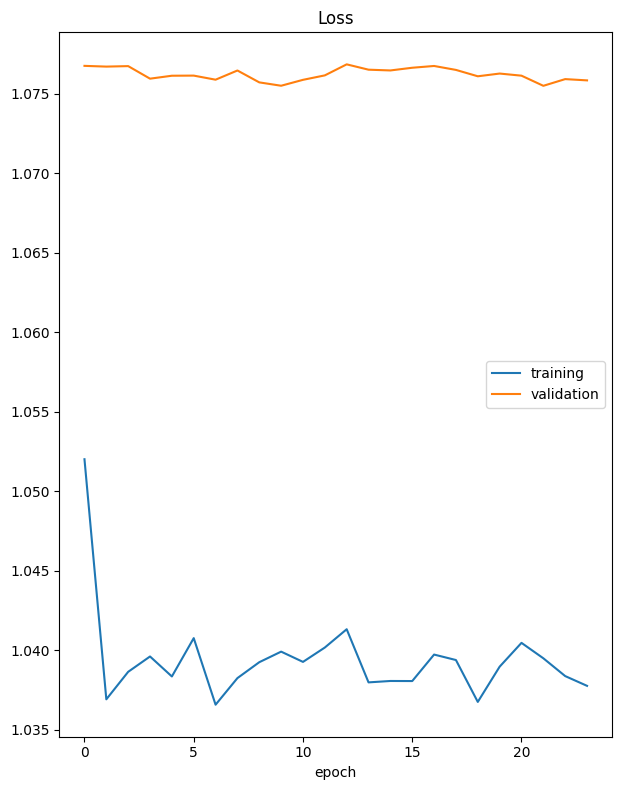

Loss
	training         	 (min:    1.037, max:    1.052, cur:    1.038)
	validation       	 (min:    1.075, max:    1.077, cur:    1.076)
Silhouette Score for Trial 69, Epoch 24: 0.2111

                          Trial 69 
                          Epoch [25/25] 
                          Step [1/42] 
                          Loss: 1.0281 
                          Pairwise: 0.0215
                          SupCR: 6.4837
                          Decorr: 0.0430
                          


In [ ]:
study = optuna.create_study(
    sampler=optuna.samplers.TPESampler(n_startup_trials=20),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=10),
    direction='maximize'
    )
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print(f"Best Trial: {best_trial.number}")
print(f"  Hyperparameters: {best_trial.params}")
print(f"  Silhouette Score: {best_trial.value:.4f}")

In [ ]:
best_trial = study.best_trial
print(f"Best Trial: {best_trial.number}")
print(f"  Hyperparameters: {best_trial.params}")
print(f"  Silhouette Score: {best_trial.value:.4f}")

Best Trial: 98
  Hyperparameters: {'alpha': 1.582357979569878, 'beta': 0.19463422433548871, 'gamma': 0.10634716185557715, 'gamma_t': 0.2394703262033405, 'gamma_threshold': 1.0280389428555952, 'lr': 1.6594036704629273e-05, 'weight_decay': 0.0003302265507633164, 'eta_min': 7.855694412172875e-06}
  Silhouette Score: 0.3399


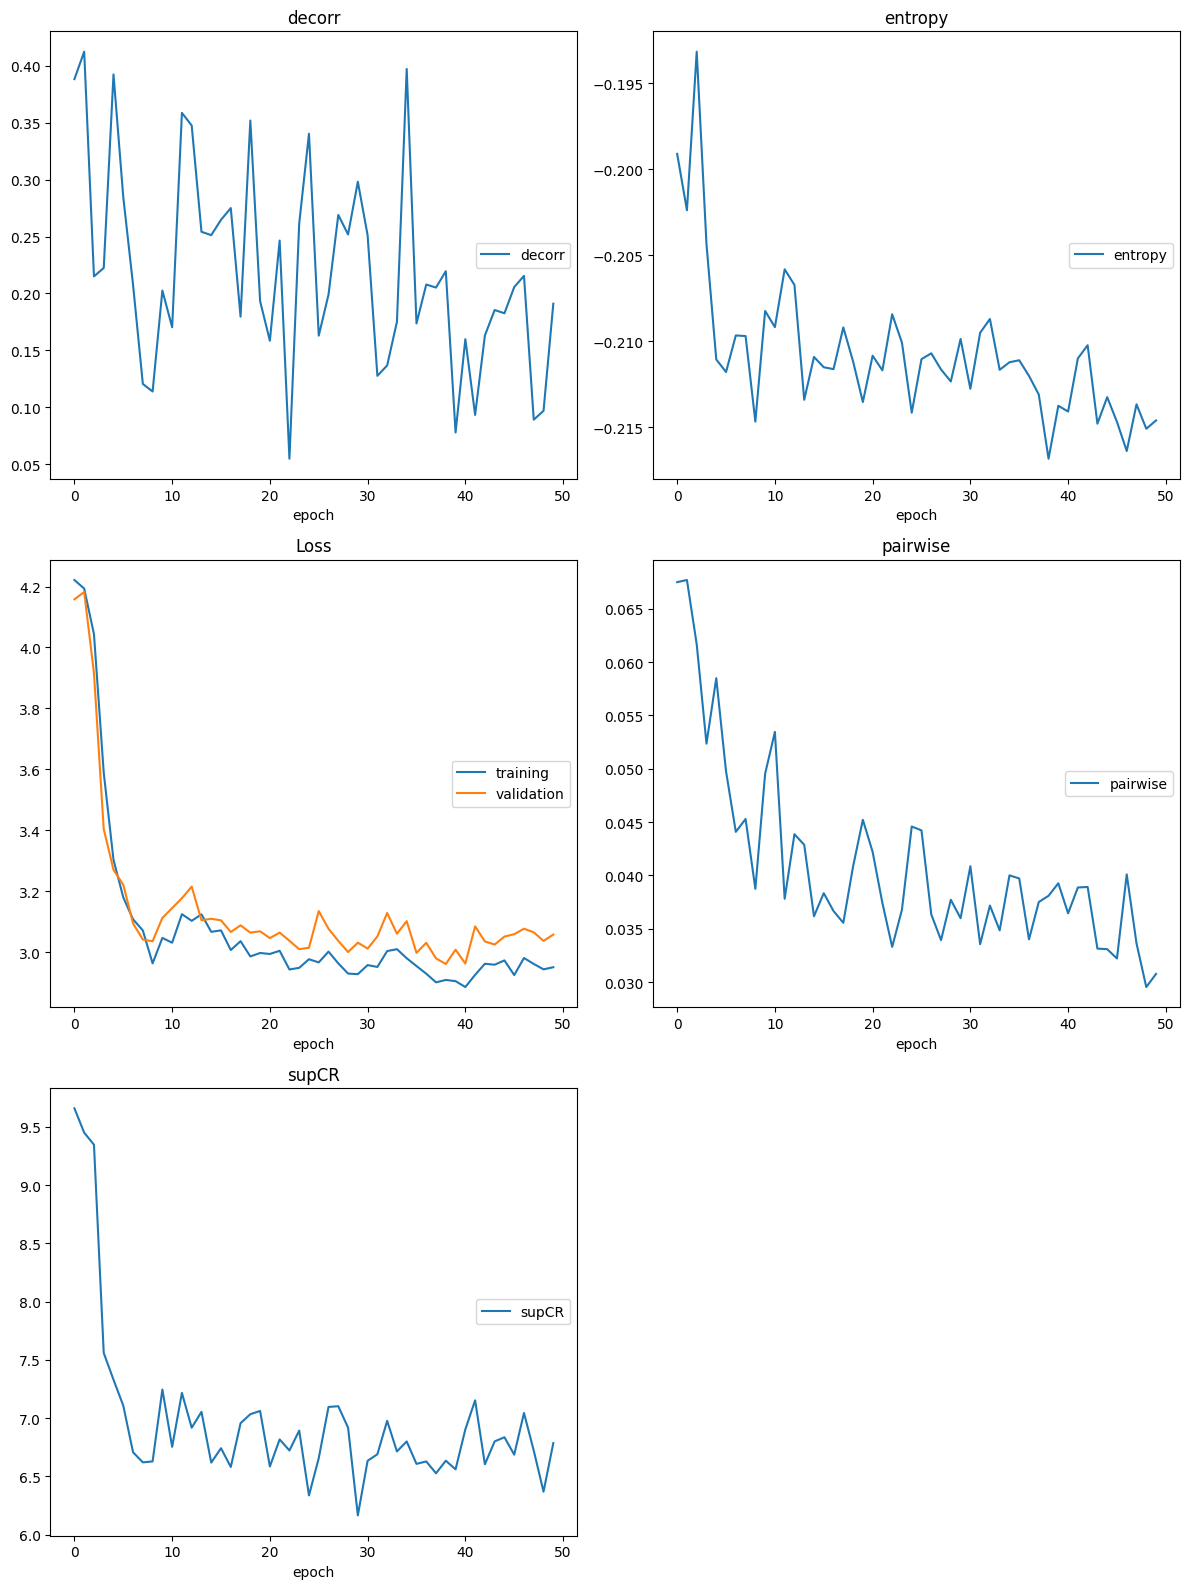

decorr
	decorr           	 (min:    0.055, max:    0.412, cur:    0.191)
entropy
	entropy          	 (min:   -0.217, max:   -0.193, cur:   -0.215)
Loss
	training         	 (min:    2.885, max:    4.222, cur:    2.950)
	validation       	 (min:    2.961, max:    4.182, cur:    3.058)
pairwise
	pairwise         	 (min:    0.030, max:    0.068, cur:    0.031)
supCR
	supCR            	 (min:    6.166, max:    9.658, cur:    6.786)
Milestone Model Saved at Epoch 50
{'train_loss': 2.9504529408046176, 'val_loss': 3.057726343472799, 'pairwise_loss': 0.030761700123548508, 'supCR_loss': 6.785958766937256, 'entropy_loss': -0.21460191905498505, 'decorr_loss': 0.1910056173801422}


In [12]:
loss_fn = CompositeLoss(alpha=1.4805552964425241, beta=0.10957664692923388, delta=0.27603637665919395, gamma=0.3936558399280522, gamma_t=0.11599898411069617, gamma_threshold=0.7697833400746035)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5.0486596860774235e-05, weight_decay=1.3896401991294737e-06)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=8.97376608102587e-06)
scaler = torch.amp.GradScaler()

train_ds = TextVectorDataset(training_data)
val_ds = TextVectorDataset(validation_data)

train_loader = DataLoader(train_ds, batch_size=physical_batch_size, shuffle=True)   
val_loader = DataLoader(val_ds, batch_size=physical_batch_size, shuffle=False)

history = train_model(model, train_loader, val_loader, optimizer, loss_fn, num_epochs, 'cuda', scheduler, scaler, accumulation_steps, output_dir)
print(history)

In [ ]:
from sklearn.model_selection import KFold
from livelossplot.outputs import MatplotlibPlot
import matplotlib.pyplot as plt
#combine datasets and do k-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
combined_data = pd.concat([training_data, validation_data], ignore_index=True)
best_val_loss = float('inf')
for fold, (train_idx, val_idx) in enumerate(kf.split(combined_data)):
    print(f"Fold {fold+1}")
    model = SentenceTransformer(modules=modules_with_reduction)
    model.to(device)
    num_epochs = 50

    loss_fn = CompositeLoss(alpha=2.0, beta=5.0, gamma=0.1)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler()

    train_subset = combined_data.iloc[train_idx]
    val_subset = combined_data.iloc[val_idx]
    
    train_ds = TextVectorDataset(train_subset)
    val_ds = TextVectorDataset(val_subset)

    train_loader = DataLoader(train_ds, batch_size=physical_batch_size, shuffle=True)   
    val_loader = DataLoader(val_ds, batch_size=physical_batch_size, shuffle=False)

    output_dir_fold = output_dir / f"fold_{fold+1}" 
    output_dir_fold.mkdir(parents=True, exist_ok=True)

    image_name = output_dir_fold / f"fold_{fold+1}_training_plot.png"
    image_name = str(image_name)  # Convert Path to string for MatplotlibPlot
    plot = MatplotlibPlot(figpath=image_name)  # Create a new plot instance for this fold
    kf_plot = PlotLosses(outputs=[plot])
    
    history = train_model(model, train_loader, val_loader, optimizer, loss_fn, 
                          num_epochs, 'cuda', scheduler, scaler, accumulation_steps, 
                          output_dir_fold, plotloss=kf_plot)
    
    print(f"Completed Fold {fold+1}")